Generated data shape: (100, 2)
------------------------------


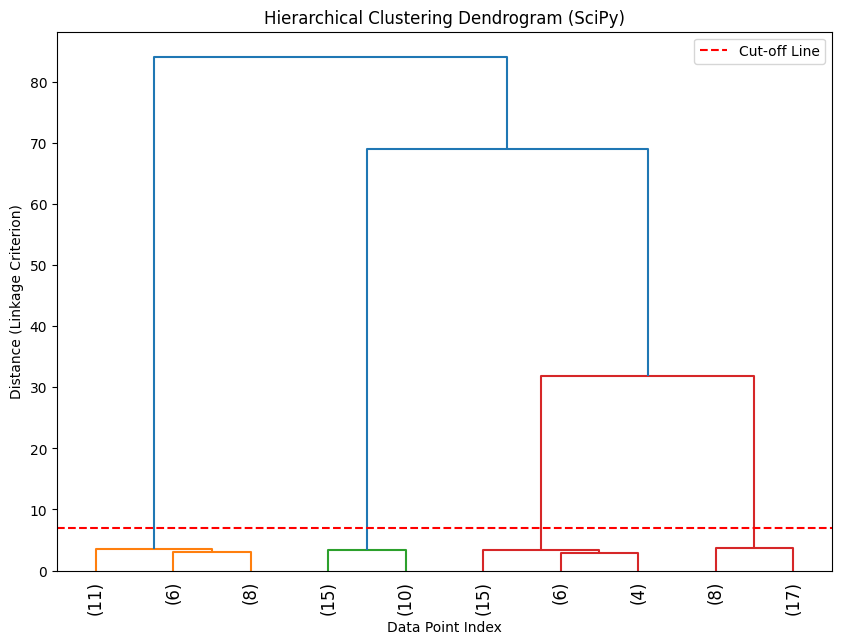

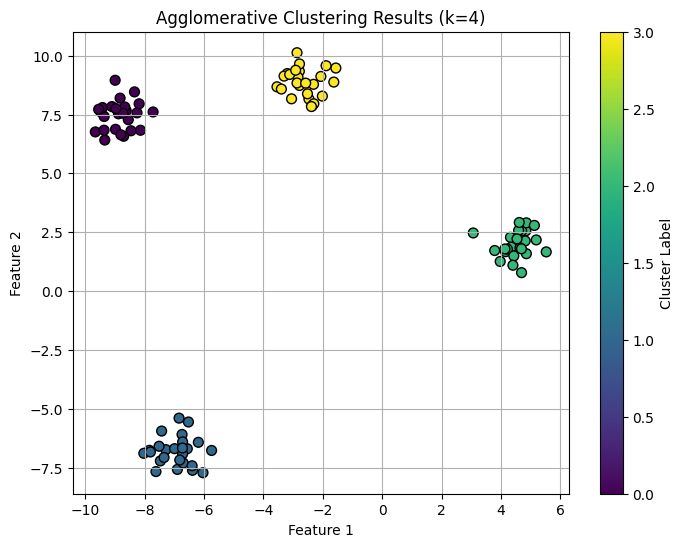

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# --- 1. Generate Synthetic Data ---
# We'll create 100 data points with 2 features (X, y coordinates)
# and an intrinsic structure of 4 'blobs' (clusters) for visualization.
X, y_true = make_blobs(n_samples=100, centers=4, cluster_std=0.60, random_state=42)

print(f"Generated data shape: {X.shape}")
print("-" * 30)

# --- 2. Hierarchical Clustering using SciPy (for Dendrogram) ---

# The linkage function performs the hierarchical clustering.
# 'ward' method minimizes the variance of the clusters being merged.
# 'euclidean' is the standard distance metric used.
linked = linkage(X, method='ward', metric='euclidean')

# --- 3. Plot the Dendrogram ---
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (SciPy)")
plt.xlabel("Data Point Index")
plt.ylabel("Distance (Linkage Criterion)")

# Generate and plot the dendrogram
# truncate_mode='lastp' shows only the last 'p' merged clusters
# p=10 shows the last 10 merged clusters for a cleaner plot
dendrogram(
    linked,
    orientation='top',
    truncate_mode='lastp',
    p=10,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
)
plt.axhline(y=7, color='r', linestyle='--', label='Cut-off Line')
plt.legend()
plt.show()

# --- 4. Applying Agglomerative Clustering using Scikit-learn ---

# Based on the dendrogram, we can choose the number of clusters (k).
# If we cut the dendrogram at a distance of ~7 (red dashed line),
# it intersects 4 main branches, suggesting k=4.
n_clusters_chosen = 4

# Initialize the Agglomerative Clustering model
# We use the same 'linkage' and 'metric' as used for the dendrogram.
hac = AgglomerativeClustering(n_clusters=n_clusters_chosen, metric='euclidean', linkage='ward')

# Fit the model and predict the cluster labels
hac_labels = hac.fit_predict(X)

# --- 5. Visualize the Final Clusters ---
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=hac_labels, cmap='viridis', marker='o', s=50, edgecolors='k')
plt.title(f"Agglomerative Clustering Results (k={n_clusters_chosen})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()